In [1]:
%matplotlib inline
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# Resolve repo root and service directory
repo_root = Path(r"C:\Users\Harsh\AeroSentinel")
ai_service_dir = repo_root / "ai-service"

if str(ai_service_dir) not in sys.path:
    sys.path.insert(0, str(ai_service_dir))

val_path = repo_root / "data" / "processed" / "val_dataset.parquet"
val_df = pd.read_parquet(val_path)

# Load artifacts
hotspot_art = joblib.load(ai_service_dir / "models" / "artifacts" / "hotspot_classifier_v1.joblib")
forecast_art = joblib.load(ai_service_dir / "models" / "artifacts" / "forecast_regressors_v1.joblib")

hotspot_model = hotspot_art["model"]
features = hotspot_art["feature_cols"]
threshold = hotspot_art.get("operational_threshold", 0.20)

target_pm25_col = "pm25_clean" if "pm25_clean" in val_df.columns else "pm25"
y_val = (val_df[target_pm25_col].fillna(0.0) >= 60.0).astype(int)
X_val = val_df[features].fillna(0.0)
val_probs = hotspot_model.predict_proba(X_val)[:, 1]

print(f"Validation records: {len(val_df):,}")
print("Artifacts loaded successfully.")

c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCal

Validation records: 10,528
Artifacts loaded successfully.


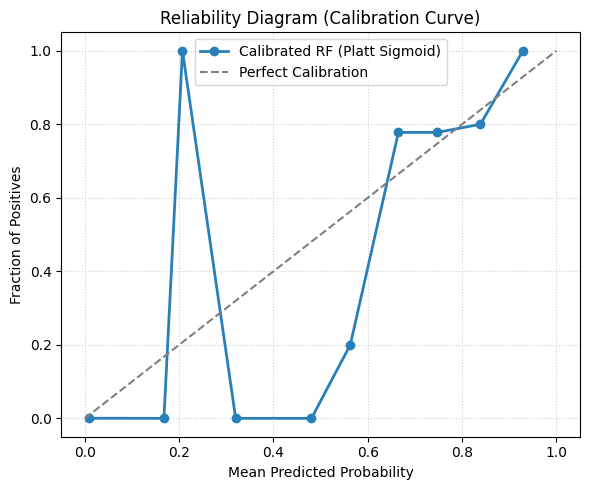

In [2]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_val, val_probs, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Calibrated RF (Platt Sigmoid)", color="#2980b9")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Reliability Diagram (Calibration Curve)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

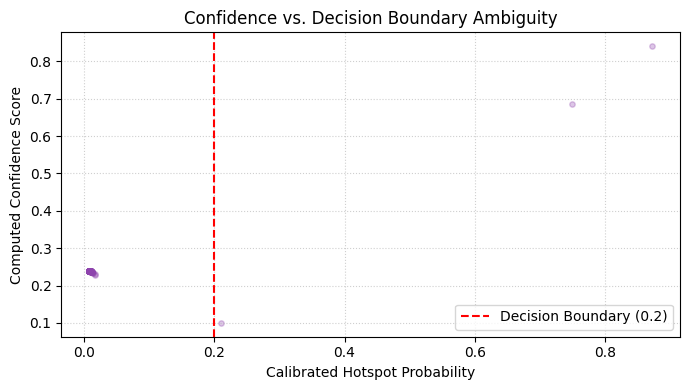

In [3]:
# Confidence scoring rule: penalizes values near the 0.20 operational threshold
def compute_confidence(prob, operational_threshold=0.20):
    distance_to_boundary = np.abs(prob - operational_threshold)
    base_confidence = np.clip(
        distance_to_boundary / max(operational_threshold, 1.0 - operational_threshold), 
        0.10, 
        1.00
    )
    return base_confidence

confidences = compute_confidence(val_probs, threshold)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(val_probs[::20], confidences[::20], alpha=0.3, color="#8e44ad", s=15)
ax.axvline(threshold, color="red", linestyle="--", label=f"Decision Boundary ({threshold})")
ax.set_xlabel("Calibrated Hotspot Probability")
ax.set_ylabel("Computed Confidence Score")
ax.set_title("Confidence vs. Decision Boundary Ambiguity")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
# Traceability & evidence inspection on top hotspot predictions
high_risk_idx = np.where(val_probs >= threshold)[0]
sample_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

sample_row = val_df.iloc[sample_idx]
sample_prob = val_probs[sample_idx]
sample_conf = confidences[sample_idx]

evidence = {
    "predicted_hotspot_probability": round(float(sample_prob), 3),
    "operational_threshold": threshold,
    "confidence_score": round(float(sample_conf), 3),
    "observed_pm25": float(sample_row[target_pm25_col]),
    "contributing_features": {
        feat: round(float(sample_row[feat]), 2)
        for feat in features[:5] if feat in sample_row
    },
    "governance_note": "Associated observations only. Does not infer ground truth causality."
}

pd.DataFrame([evidence])

,predicted_hotspot_probability,operational_threshold,confidence_score,observed_pm25,contributing_features,governance_note
0,0.32,0.2,0.15,7.01,"{'latitude': 18.45, 'longitude': 73.86, 'pm10'...",Associated observations only. Does not infer g...
